# Run this first !
Ensures correct libraries and imports data

In [1]:

# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-23")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-23")
met = loading.load(DATA, "all_metrics.csv", "2026-09-23")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


# Sentence pre-processing (stop words, speaker names and greetings etc)
This is just a starting point as there are several oddities - for example greeting words mean the Bert Emotion skews towards "Joy" and some stopwords such as "us" seems to be treated as a plural of "u" - hence needs removing. Also need to work out how to differentiate between "credit" and "Credit Suisse" as both are valid but cannot be treated as the same

### Import ntlk

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [3]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['mike', 'mayo'],
 ['todd', 'tuckner'],
 ['charles', 'w.', 'peabody'],
 ['tom', 'hallett'],
 ['jim', 'mitchell'],
 ['anke', 'reingen'],
 ['sarah', 'youngwood'],
 ['chris', 'hallam'],
 ['sarah', 'mackey'],
 ['john', 'mcdonald']]

### Pre-processing Function

In [4]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]
    

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome",
    "mr", "mrs", "ms"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [5]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
5                                   Please stand by.   
6  At this time, I would like to turn the call ov...   
7                       Mr. Barnum, please go ahead.   
8                Thanks, and good morning, everyone.   
9  The presentation is available on our website, ...   

                                        cleaned_text  
0                                                 []  
1           [jpmorgan, chase, first, earnings, call]  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
5                                    [please, stand] 

# UBS Data

In [6]:
# Create dataframe with bank = ubs
ubs_data = data[data['bank'] == 'UBS'].copy()
print(ubs_data.shape)
ubs_data.head(2)

(4714, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14594,1,"Thank you, Sarah, good morning, everyone.",[everyone]
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14595,2,I am happy to be back here with all of you.,"[happy, back]"


## Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

In [7]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    ubs_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7675.58it/s]


In [8]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
ubs_data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
ubs_data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    ubs_data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [77]:
ubs_data.head(5)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14594,...,"Thank you, Sarah, good morning, everyone.",[everyone],anger,0.729607,0.729607,0.182400,0.017210,0.057599,0.007096,0.006089
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14595,...,I am happy to be back here with all of you.,"[happy, back]",joy,0.995883,0.000551,0.995883,0.000375,0.001802,0.001019,0.000370
4807,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14596,...,And it is an honor and privilege to lead UBS o...,"[honor, privilege, lead, ubs, especially, pivo...",joy,0.990937,0.002844,0.990937,0.001494,0.003068,0.000985,0.000672
4808,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14597,...,"First of all, I’d like to thank Ralph, the man...","[first, id, like, ralph, management, team, emp...",joy,0.874219,0.075282,0.874219,0.000714,0.034093,0.013854,0.001837
4809,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14598,...,"During this time, UBS delivered record results...","[time, ubs, delivered, record, result, continu...",joy,0.996476,0.000659,0.996476,0.000505,0.001307,0.000728,0.000325


## Fix colours for emotions

In [71]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [66]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = ubs_data[(ubs_data['speaker_role'] == 'management') & (ubs_data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Sergio P. Ermotti' 'Sarah Youngwood' 'Todd Tuckner']


In [67]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = ubs_data[(ubs_data['speaker_role'] == 'management') & (ubs_data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Sergio P. Ermotti' 'Sarah Youngwood' 'Todd Tuckner']


All of the 3 speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

## Calculate quarterly statistics 
Check emotion distributions and look for outliers

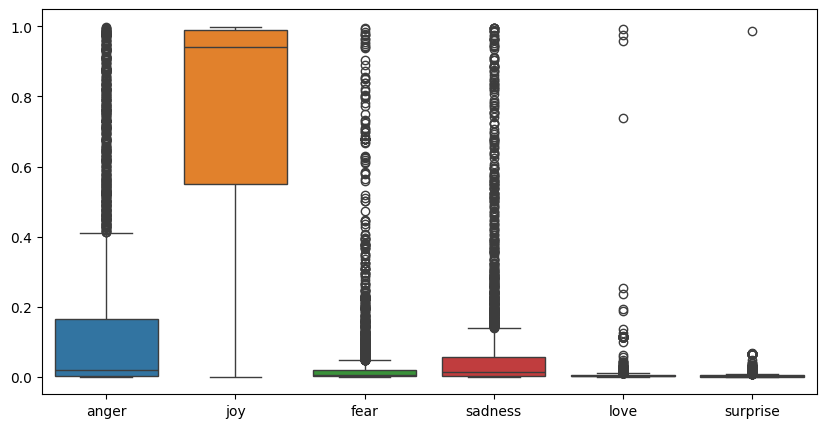

In [68]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
ubs_management_data = ubs_data[ubs_data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=ubs_management_data.iloc[:, -6:])
plt.show()



There are some significant outliers in the data for all the emotions. Hence use the median rather than the mean

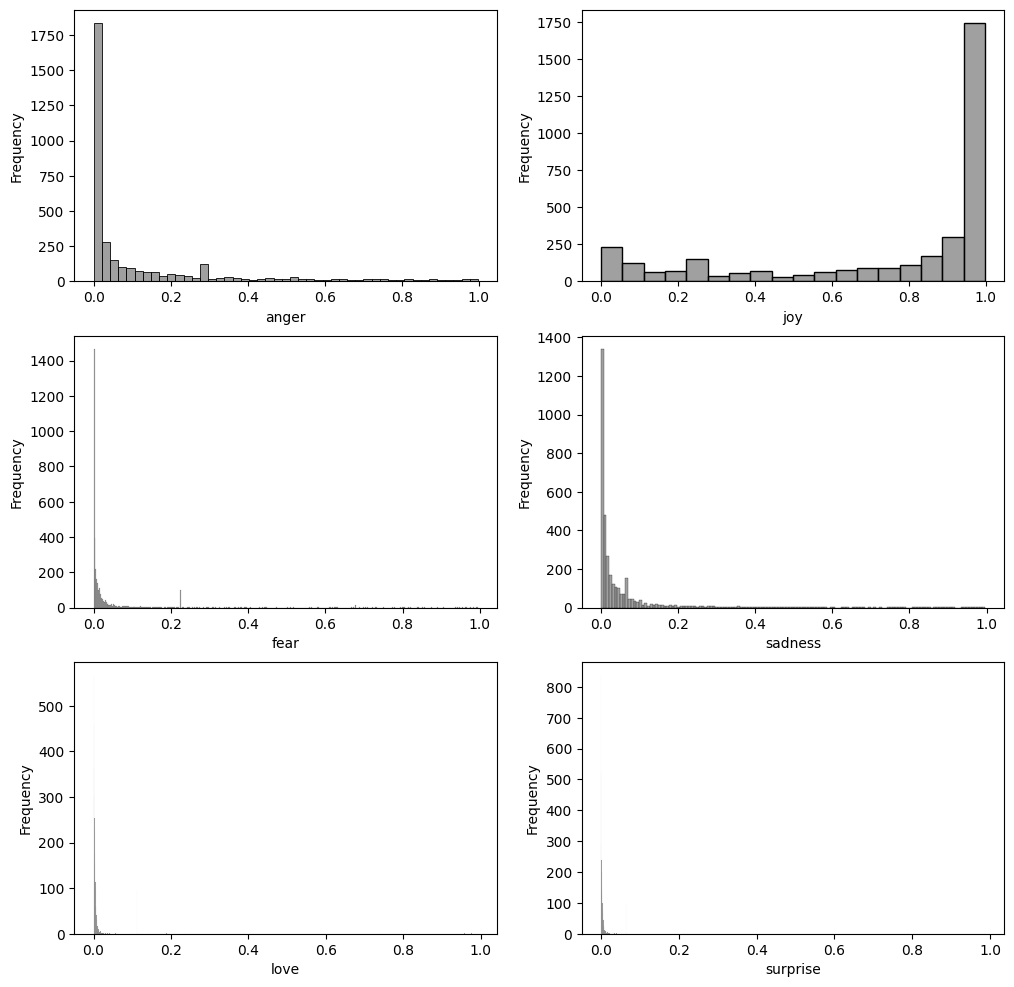

In [88]:
# Create a 3x2 grid of histograms for each emotion column
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
emotion_columns = ubs_management_data.columns[-6:]
for i, emotion in enumerate(emotion_columns):
    ax = axes[i // 2, i % 2]
    sns.histplot(data=ubs_management_data, x=emotion, ax=ax, color='grey')
    ax.set_xlabel(emotion)
    ax.set_ylabel('Frequency')


All the distributions are skewed towards the low values, apart from joy

### Presentation Section for Speaker Role = Management

In [96]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
ubs_emotion_stats = ubs_data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
ubs_emotion_stats = ubs_emotion_stats[ubs_emotion_stats['speaker_role'] != 'analyst']
ubs_emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2023-Q1,anger,management,prepared,0.708872,0.194897
2,2023-Q1,anger,management,qa,0.517480,0.251828
4,2023-Q1,fear,management,prepared,0.941451,0.228856
5,2023-Q1,fear,management,qa,0.799631,0.169760
7,2023-Q1,joy,management,prepared,0.967801,0.135048
8,2023-Q1,joy,management,qa,0.972941,0.138532
11,2023-Q1,sadness,management,prepared,0.547714,0.118052
12,2023-Q1,sadness,management,qa,0.665126,0.211810
15,2023-Q2,anger,management,prepared,0.674059,0.181752
16,2023-Q2,anger,management,qa,0.522994,0.232792


In [104]:
# Calculate max and mean values for std_score
ubs_emotion_std_max = ubs_emotion_stats.groupby('main_emotion')['std_score'].max()
ubs_emotion_std_mean = ubs_emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(ubs_emotion_std_max)
print("\nMean std_score per emotion:")
print(ubs_emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.343535
fear        0.365154
joy         0.215658
love        0.167770
sadness     0.339947
surprise    0.000000
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.216918
fear        0.165427
joy         0.145048
love        0.055923
sadness     0.177164
surprise    0.000000
Name: std_score, dtype: float64


## Positive Emotions

In order to build a comparison with FinBert, the BertEmotion categories will be split into:  

* POSITIVE = Love & Joy
* NEGATIVE = Anger, Fear and Sadness
* NEUTRAL/ OTHER = Surprise

In [144]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
ubs_diff_emotion_stats = ubs_emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
ubs_diff_emotion_stats = ubs_diff_emotion_stats.fillna(0)
ubs_diff_emotion_stats['diff'] = ubs_diff_emotion_stats['qa'] - ubs_diff_emotion_stats['prepared']

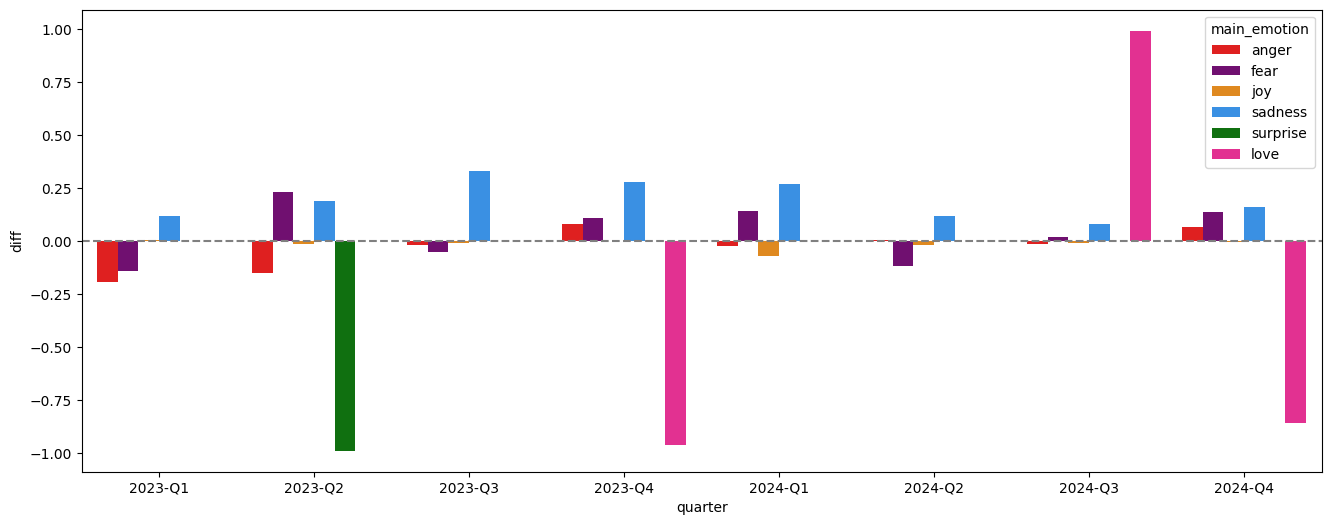

In [145]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
sns.barplot(data=ubs_diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.axhline(0, linestyle='--', color='gray')

### Positive Emotions: Love & Joy
Plot the median emotion score by quarter to check for the dominant emotion in both the prepared presentation and the Q&A section

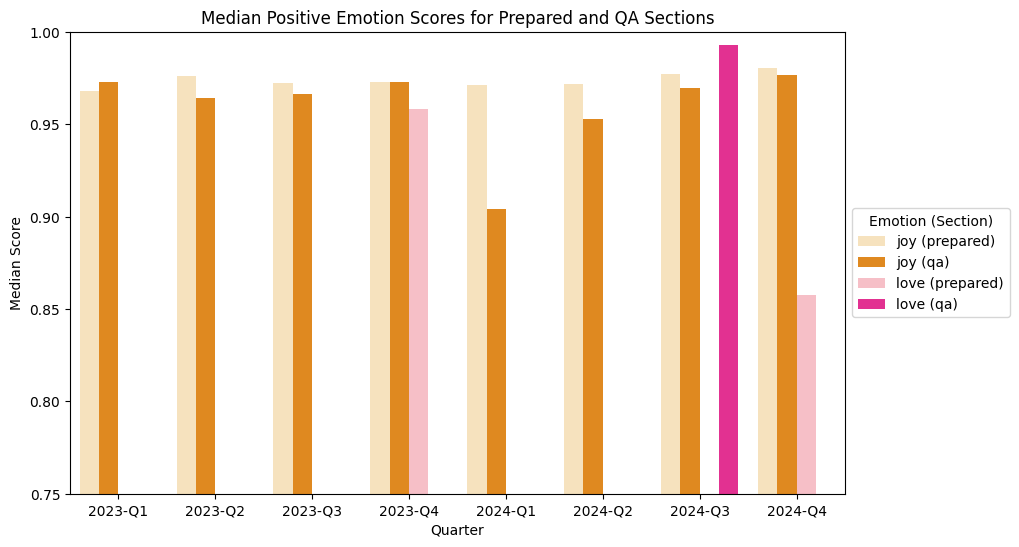

In [146]:
# Plot Positive Emotion Scores for prepared and QA sections using "Joy" and "Love" emotions
# "Joy" = dark orange, "Love" = deeppink
# Use a single grouped bar plot with a combined emotion+section hue so all 4 bars appear per quarter

positive_emotions = ["joy", "love"]
ubs_emotion_positive = ubs_emotion_stats[ubs_emotion_stats['main_emotion'].isin(positive_emotions)].copy()

# Combine emotion and section into one hue column, e.g. "joy (prepared)"
ubs_emotion_positive["emotion_section"] = (
    ubs_emotion_positive["main_emotion"] + " (" + ubs_emotion_positive["section"] + ")"
)

# One palette entry per combination, prepared = lighter shade, qa = full colour
combined_palette = {
    "joy (prepared)": "moccasin",
    "joy (qa)": "darkorange",
    "love (prepared)": "lightpink",
    "love (qa)": "deeppink",
}

plt.figure(figsize=(10, 6))
sns.barplot(
    data=ubs_emotion_positive,
    x="quarter",
    y="median_score",
    hue="emotion_section",
    hue_order=list(combined_palette.keys()),
    palette=combined_palette,
    errorbar=None,
)

# set y limits
plt.ylim(0.75, 1)
# Plot legend to the side of the plot
plt.legend(title="Emotion (Section)", loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Median Positive Emotion Scores for Prepared and QA Sections")
plt.xlabel("Quarter")
plt.ylabel("Median Score")
plt.show()

Plot the differences between the prepared and Q&A sections to ascertain any changes

/var/folders/c9/gw94qsq971z4r0zg7fh_c7240000gn/T/ipykernel_26874/3995862486.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))


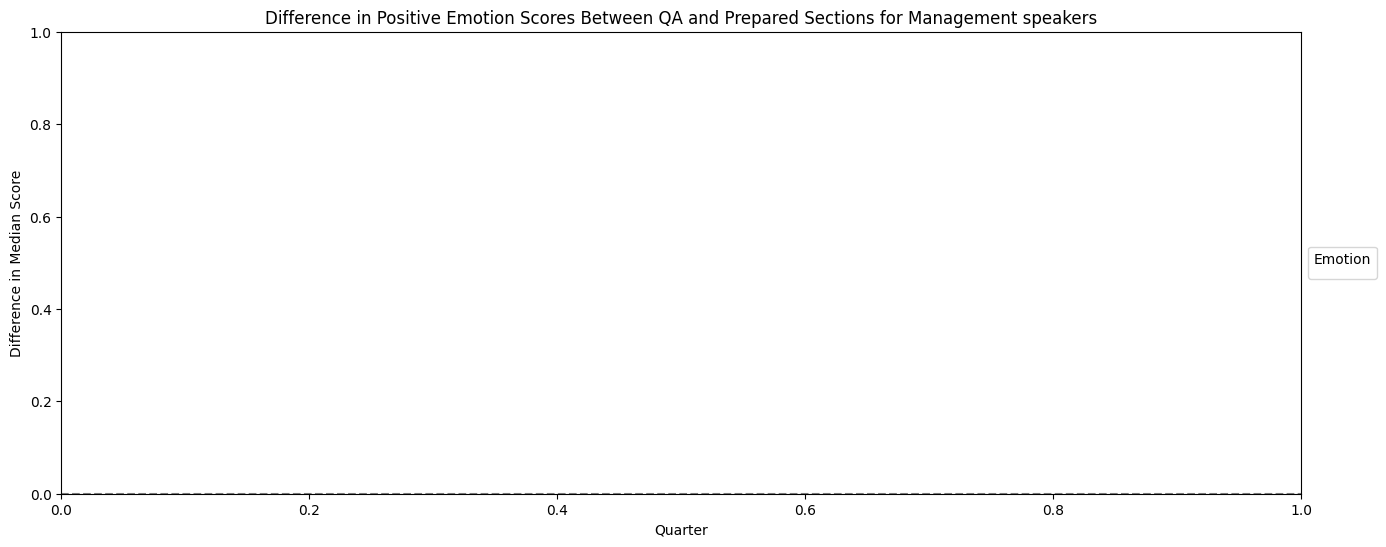

In [155]:
# Plot results as bar chart for "joy" and "love" emotions only
ubs_diff_positive_emotion_stats = ubs_diff_emotion_stats[ubs_diff_emotion_stats['main_emotion'].isin(['joy', 'love'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=ubs_diff_positive_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.axhline(0, linestyle='--', color='gray')
plt.title("Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### Negative Emotions: Sadness, Fear & Anger

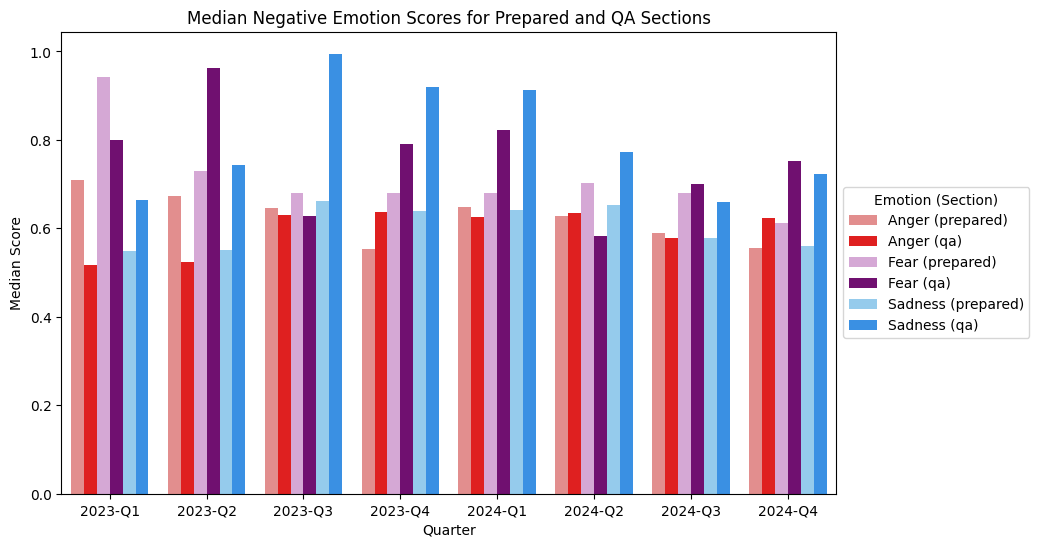

In [153]:
# Plot Negative Emotion Scores for prepared and QA sections using "Anger", "Fear" and "Sadness"  emotions
# "Anger" = red, "Fear" = purple and "Sadness" = dodgerblue
# Use a single grouped bar plot with a combined emotion+section hue so all bars appear per quarter

negative_emotions = ["anger", "fear", "sadness"]
ubs_emotion_negative = ubs_emotion_stats[ubs_emotion_stats['main_emotion'].isin(negative_emotions)].copy()

# Combine emotion and section into one hue column, e.g. "anger (prepared)"
ubs_emotion_negative["emotion_section"] = (
    ubs_emotion_negative["main_emotion"].str.capitalize() + " (" + ubs_emotion_negative["section"].str.lower() + ")"
)   

# One palette entry per combination, prepared = lighter shade, qa = full colour
combined_palette_negative = {
    "Anger (prepared)": "lightcoral",
    "Anger (qa)": "red",
    "Fear (prepared)": "plum",
    "Fear (qa)": "purple",
    "Sadness (prepared)": "lightskyblue",
    "Sadness (qa)": "dodgerblue",
}

plt.figure(figsize=(10, 6))
sns.barplot(
    data=ubs_emotion_negative,
    x="quarter",
    y="median_score",
    hue="emotion_section",
    hue_order=list(combined_palette_negative.keys()),
    palette=combined_palette_negative,
    errorbar=None,
)

# Plot legend to the side of the plot
plt.legend(title="Emotion (Section)", loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Median Negative Emotion Scores for Prepared and QA Sections")
plt.xlabel("Quarter")
plt.ylabel("Median Score")
plt.show()

/var/folders/c9/gw94qsq971z4r0zg7fh_c7240000gn/T/ipykernel_26874/2489385734.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))


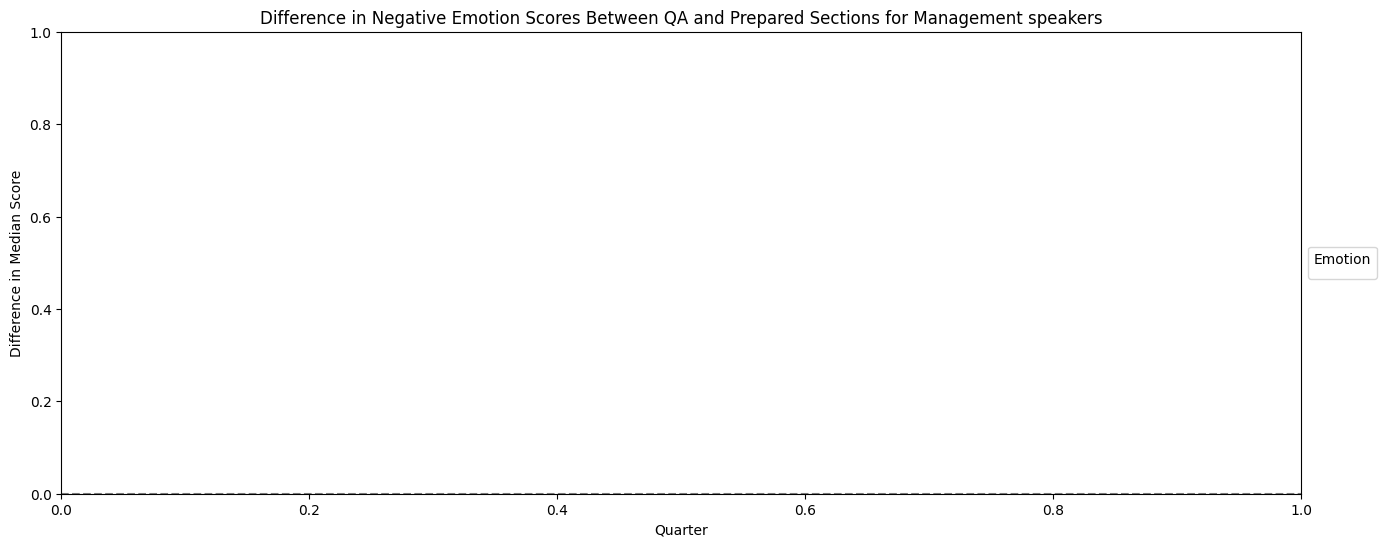

In [154]:
# Plot results as bar chart for "anger", "fear" and "sadness" emotions only
ubs_diff_emotion_stats = ubs_diff_emotion_stats[ubs_diff_emotion_stats['main_emotion'].isin(['anger', 'fear', 'sadness'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=ubs_diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.axhline(0, linestyle='--', color='gray')
plt.title("Difference in Negative Emotion Scores Between QA and Prepared Sections for Management speakers")
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## Differences in emotions per speaker

### Todd Tuckner


In [43]:
# Create a data frame for speaker name = Todd Tuckner using speaker_qa_dfs  and speaker_p_dfs
todd_tuckner_qa_df = speaker_qa_dfs.get("Todd Tuckner", pd.DataFrame())
todd_tuckner_p_df = speaker_p_dfs.get("Todd Tuckner", pd.DataFrame())

todd_tuckner_combined_df = pd.concat([todd_tuckner_qa_df, todd_tuckner_p_df], ignore_index=True)
todd_tuckner_combined_df.head(5)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
0,UBS,2023-Q2,earnings,2023-08-31,7,qa,management,Todd Tuckner,NaN,15463,...,"Hi, Alastair.",[],anger,0.291548,0.291548,0.236256,0.224192,0.070036,0.112292,0.065676
1,UBS,2023-Q2,earnings,2023-08-31,7,qa,management,Todd Tuckner,NaN,15464,...,Yeah.,[],anger,0.291548,0.291548,0.236256,0.224192,0.070036,0.112292,0.065676
2,UBS,2023-Q2,earnings,2023-08-31,7,qa,management,Todd Tuckner,NaN,15465,...,In terms of the speed at which we expect to ta...,"[term, speed, expect, take, cost]",joy,0.410346,0.228295,0.410346,0.148468,0.197847,0.008405,0.006638
3,UBS,2023-Q2,earnings,2023-08-31,7,qa,management,Todd Tuckner,NaN,15466,...,"As Sergio and I said, we've been operating at ...","[said, weve, operating, pace, term, cost, take...",anger,0.814651,0.814651,0.159734,0.008177,0.009443,0.005382,0.002612
4,UBS,2023-Q2,earnings,2023-08-31,7,qa,management,Todd Tuckner,NaN,15467,...,In terms of in particular restructuring the pa...,"[term, particular, restructuring, part, credit...",joy,0.761512,0.146738,0.761512,0.034700,0.048200,0.004912,0.003937


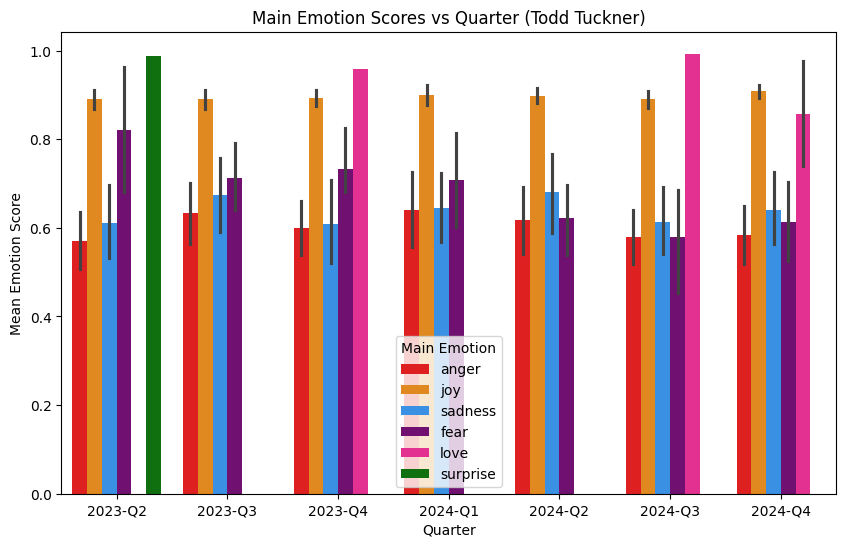

In [44]:
# Create scatter plot of main_emotion scores vs quarter with hue = main_emotion for Todd Tuckner split by section
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=todd_tuckner_combined_df,
    x="quarter",
    y="main_emotion_score",
    #style="section",
    hue="main_emotion",
    palette=emotion_palette
)
plt.title("Main Emotion Scores vs Quarter (Todd Tuckner)")
plt.xlabel("Quarter")
plt.ylabel("Mean Emotion Score")
plt.legend(title="Main Emotion")
plt.show()

In [45]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS) for Todd Tuckner split by section
todd_tuckner_ubs_emotion_stats = todd_tuckner_combined_df.groupby(["quarter", "main_emotion", "section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
todd_tuckner_ubs_emotion_stats.head(10)


,quarter,main_emotion,section,median_score,std_score
0,2023-Q2,anger,prepared,0.546103,0.187114
1,2023-Q2,anger,qa,0.483281,0.237291
2,2023-Q2,fear,prepared,0.679915,0.000000
3,2023-Q2,fear,qa,0.963366,0.000000
4,2023-Q2,joy,prepared,0.964523,0.159980
5,2023-Q2,joy,qa,0.966029,0.145001
6,2023-Q2,sadness,prepared,0.545148,0.140069
7,2023-Q2,sadness,qa,0.687119,0.184424
8,2023-Q2,surprise,prepared,0.987155,0.000000
9,2023-Q3,anger,prepared,0.646491,0.156942


In [46]:
# Calculate mean value of the std_score column
todd_tuckner_ubs_emotion_std_mean = todd_tuckner_ubs_emotion_stats["std_score"].mean()
print("Average standard deviation of emotion scores:", todd_tuckner_ubs_emotion_std_mean)

# Find largest value of the std_score column
todd_tuckner_ubs_emotion_std_max = todd_tuckner_ubs_emotion_stats["std_score"].max()
print("Largest standard deviation of emotion scores:", todd_tuckner_ubs_emotion_std_max)


Average standard deviation of emotion scores: 0.15169691841551894
Largest standard deviation of emotion scores: 0.26805723831175615


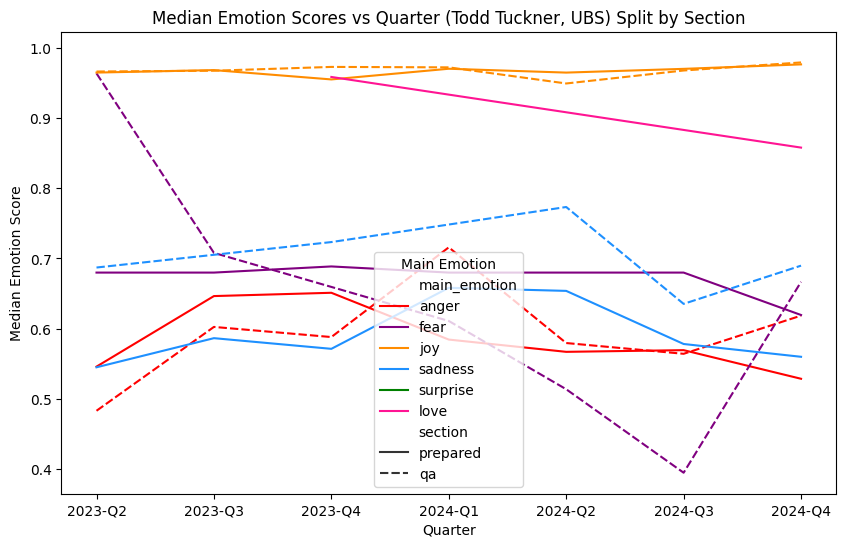

In [47]:
# Plot median emotion per quarter for Todd Tuckner (UBS) split by section
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=todd_tuckner_ubs_emotion_stats,
    x="quarter",
    y="median_score",
    hue="main_emotion",
    style="section",
    palette=emotion_palette
)
plt.title("Median Emotion Scores vs Quarter (Todd Tuckner, UBS) Split by Section")
plt.xlabel("Quarter")
plt.ylabel("Median Emotion Score")
plt.legend(title="Main Emotion")
plt.show()

In [48]:
# Subtract median score of prepared section from median score from qa section for each emotion and quarter for Todd Tuckner
todd_tuckner_ubs_emotion_diff = todd_tuckner_ubs_emotion_stats.pivot_table(
    index=["quarter", "main_emotion"],
    columns="section",
    values="median_score",
    # if there are missing values for either section, they will be ignored in the subtraction
    fill_value=0,  # if there are missing values for either section, they will be treated as 0
).reset_index()
todd_tuckner_ubs_emotion_diff["diff"] = todd_tuckner_ubs_emotion_diff["qa"] - todd_tuckner_ubs_emotion_diff["prepared"]
todd_tuckner_ubs_emotion_diff.head(10)

section,quarter,main_emotion,prepared,qa,diff
0,2023-Q2,anger,0.546103,0.483281,-0.062822
1,2023-Q2,fear,0.679915,0.963366,0.283451
2,2023-Q2,joy,0.964523,0.966029,0.001506
3,2023-Q2,sadness,0.545148,0.687119,0.141971
4,2023-Q2,surprise,0.987155,0.000000,-0.987155
5,2023-Q3,anger,0.646491,0.602593,-0.043898
6,2023-Q3,fear,0.679915,0.707955,0.028040
7,2023-Q3,joy,0.968056,0.967170,-0.000885
8,2023-Q3,sadness,0.586588,0.000000,-0.586588
9,2023-Q4,anger,0.651183,0.588174,-0.063008


In [49]:
# Add values for all emotions for 2023-Q1 as zeros as he was not present CFO role at that time
todd_tuckner_ubs_emotion_diff = pd.concat([
    pd.DataFrame({
        'quarter': ['2023-Q1'] * len(emotion_palette),
        'diff': [0] * len(emotion_palette),
        'main_emotion': list(emotion_palette.keys())
    }),
    todd_tuckner_ubs_emotion_diff
], ignore_index=True)

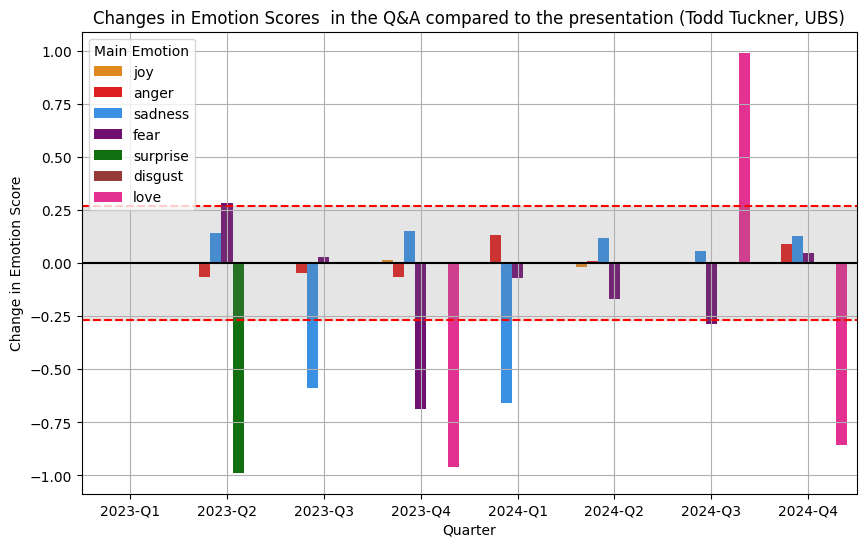

In [50]:
# Plot as changes in emotion as a bar chart
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))


sns.barplot(
    data=todd_tuckner_ubs_emotion_diff,
    x="quarter",
    y="diff",
    hue="main_emotion",
    palette=emotion_palette
)
# Plot x lines as positive and negative values of todd_tuckner_ubs_emotion_std_mean 
plt.axhline(y=todd_tuckner_ubs_emotion_std_max, color='r', linestyle='--')
plt.axhline(y=-todd_tuckner_ubs_emotion_std_max, color='r', linestyle='--')
# Add grey box between positive and negative standard deviation lines
plt.axhspan(-todd_tuckner_ubs_emotion_std_max, todd_tuckner_ubs_emotion_std_max, color='grey', alpha=0.2)
# plot x axis at zero
plt.axhline(y=0, color='black', linestyle='-')

# Add gridlines
plt.grid(True)
plt.title("Changes in Emotion Scores  in the Q&A compared to the presentation (Todd Tuckner, UBS)")
plt.xlabel("Quarter")
plt.ylabel("Change in Emotion Score")
plt.legend(title="Main Emotion")
# Save fig
plt.savefig("changes_in_emotion_scores_todd_tuckner_ubs.png")
plt.show()


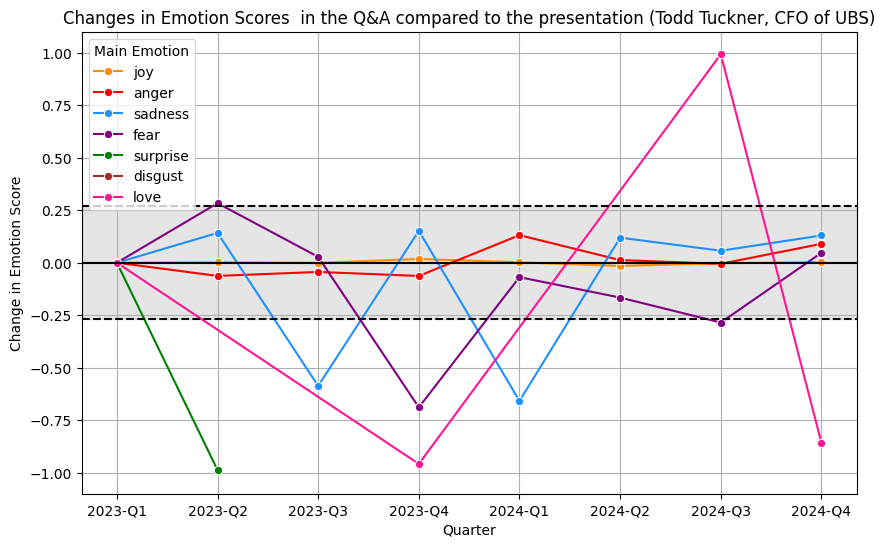

In [51]:
# Replot as line chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=todd_tuckner_ubs_emotion_diff,
    x="quarter",
    y="diff",
    hue="main_emotion",
    palette=emotion_palette,
    marker="o"
)
# Add gridlines
# Fix y scale as -1.1 to + 1.1
plt.ylim(-1.1, 1.1)
plt.grid(True)
plt.axhline(y=todd_tuckner_ubs_emotion_std_max, color='black', linestyle='--')
plt.axhline(y=-todd_tuckner_ubs_emotion_std_max, color='black', linestyle='--')
plt.axhspan(-todd_tuckner_ubs_emotion_std_max, todd_tuckner_ubs_emotion_std_max, color='grey', alpha=0.2)
plt.axhline(y=0, color='black', linestyle='-')
plt.title("Changes in Emotion Scores  in the Q&A compared to the presentation (Todd Tuckner, CFO of UBS)")
plt.xlabel("Quarter")
plt.ylabel("Change in Emotion Score")
plt.legend(title="Main Emotion")
plt.savefig("changes_in_emotion_scores_todd_tuckner_ubs_line.png")
plt.show()

Some significant emotions seen in the presentation but not the Q&A:
* Q2 2023 = Surprise
* Q3 2023 = Sadness 
* Q4 2023 = Fear & Love
* Q1 2024 = Sadness
* Q4 2024 = Love

However the only emotion that increased in the Q&A was love in Q3 2024

### Sergio P. Ermotti


In [52]:
# Create a data frame for speaker name = Sergio using speaker_qa_dfs  and speaker_p_dfs
sergio_qa_df = speaker_qa_dfs.get("Sergio P. Ermotti", pd.DataFrame())
sergio_p_df = speaker_p_dfs.get("Sergio P. Ermotti", pd.DataFrame())

sergio_combined_df = pd.concat([sergio_qa_df, sergio_p_df], ignore_index=True)
sergio_combined_df.head(5)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
0,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,14781,...,Okay.,[okay],joy,0.974035,0.008421,0.974035,0.004290,0.007776,0.003047,0.002432
1,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,14782,...,Thank you.,[],anger,0.291548,0.291548,0.236256,0.224192,0.070036,0.112292,0.065676
2,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,14783,...,"On capital requirements, you know, the situati...","[capital, requirement, know, situation, cleare...",joy,0.956487,0.019340,0.956487,0.005079,0.016585,0.001743,0.000765
3,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,14784,...,"This will, of course, have an impact on op-ris...","[course, impact, oprisk, capital, charge]",joy,0.800778,0.084990,0.800778,0.013036,0.094574,0.002597,0.004025
4,UBS,2023-Q1,earnings,2023-04-25,4,qa,management,Sergio P. Ermotti,NaN,14785,...,"So, I think this is one of the issues that Sar...","[one, issue, referred]",anger,0.824714,0.824714,0.108638,0.007595,0.040498,0.012881,0.005673


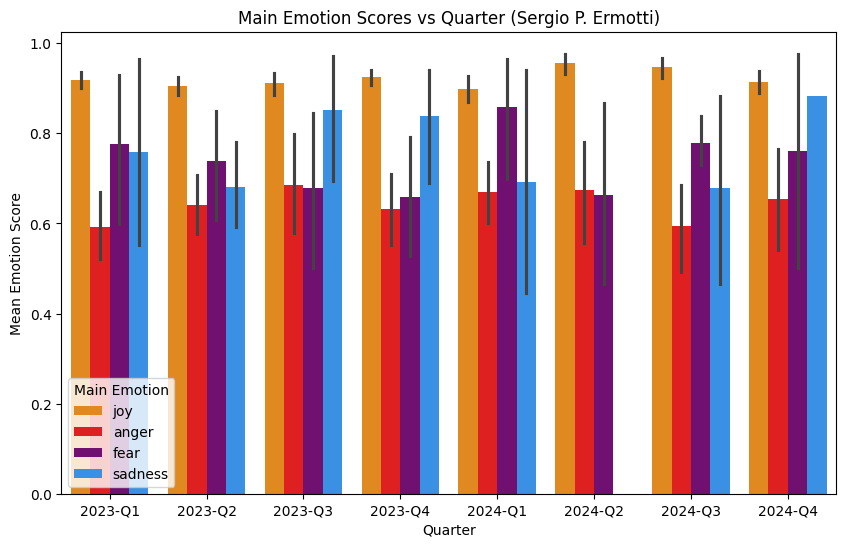

In [53]:
# Create scatter plot of main_emotion scores vs quarter with hue = main_emotion for Sergio P. Ermotti split by section
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sergio_combined_df,
    x="quarter",
    y="main_emotion_score",
    #style="section",
    hue="main_emotion",
    palette=emotion_palette
)
plt.title("Main Emotion Scores vs Quarter (Sergio P. Ermotti)")
plt.xlabel("Quarter")
plt.ylabel("Mean Emotion Score")
plt.legend(title="Main Emotion")
plt.show()

In [54]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS) for Sergio P. Ermotti split by section
sergio_ubs_emotion_stats = sergio_combined_df.groupby(["quarter", "main_emotion", "section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
sergio_ubs_emotion_stats.head(10)


,quarter,main_emotion,section,median_score,std_score
0,2023-Q1,anger,prepared,0.745398,0.221903
1,2023-Q1,anger,qa,0.501366,0.259658
2,2023-Q1,fear,prepared,0.752343,0.267440
3,2023-Q1,fear,qa,0.877827,0.250917
4,2023-Q1,joy,prepared,0.984164,0.121642
5,2023-Q1,joy,qa,0.981739,0.138188
6,2023-Q1,sadness,qa,0.760911,0.240039
7,2023-Q2,anger,prepared,0.707796,0.166058
8,2023-Q2,anger,qa,0.523778,0.231729
9,2023-Q2,fear,prepared,0.751441,0.132128


In [55]:
# Calculate mean value of the std_score column
sergio_ubs_emotion_std_mean = sergio_ubs_emotion_stats["std_score"].mean()
print("Average standard deviation of emotion scores:", sergio_ubs_emotion_std_mean)

# Find largest value of the std_score column
sergio_ubs_emotion_std_max = sergio_ubs_emotion_stats["std_score"].max()
print("Largest standard deviation of emotion scores:", sergio_ubs_emotion_std_max)


Average standard deviation of emotion scores: 0.15433217419742926
Largest standard deviation of emotion scores: 0.4569285253693385


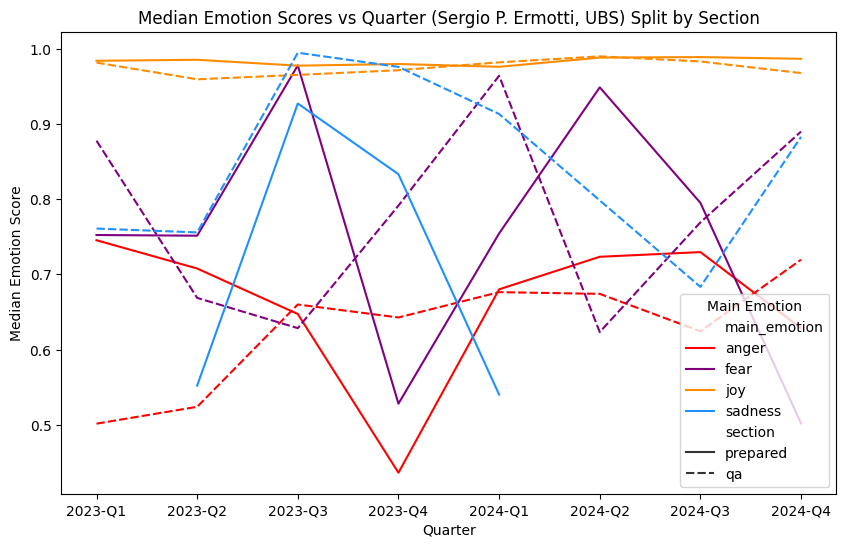

In [56]:
# Plot median emotion per quarter for Todd Tuckner (UBS) split by section
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=sergio_ubs_emotion_stats,
    x="quarter",
    y="median_score",
    hue="main_emotion",
    style="section",
    palette=emotion_palette
)
plt.title("Median Emotion Scores vs Quarter (Sergio P. Ermotti, UBS) Split by Section")
plt.xlabel("Quarter")
plt.ylabel("Median Emotion Score")
plt.legend(title="Main Emotion")
plt.show()

In [57]:
# Subtract median score of prepared section from median score from qa section for each emotion and quarter for Sergio P. Ermotti
sergio_ubs_emotion_diff = sergio_ubs_emotion_stats.pivot_table(
    index=["quarter", "main_emotion"],
    columns="section",
    values="median_score",
    # if there are missing values for either section, they will be ignored in the subtraction
    fill_value=0,  # if there are missing values for either section, they will be treated as 0
).reset_index()
sergio_ubs_emotion_diff["diff"] = sergio_ubs_emotion_diff["qa"] - sergio_ubs_emotion_diff["prepared"]
sergio_ubs_emotion_diff.head(10)

section,quarter,main_emotion,prepared,qa,diff
0,2023-Q1,anger,0.745398,0.501366,-0.244032
1,2023-Q1,fear,0.752343,0.877827,0.125484
2,2023-Q1,joy,0.984164,0.981739,-0.002425
3,2023-Q1,sadness,0.000000,0.760911,0.760911
4,2023-Q2,anger,0.707796,0.523778,-0.184018
5,2023-Q2,fear,0.751441,0.668686,-0.082755
6,2023-Q2,joy,0.985506,0.959511,-0.025994
7,2023-Q2,sadness,0.551952,0.755820,0.203868
8,2023-Q3,anger,0.647237,0.659892,0.012655
9,2023-Q3,fear,0.977969,0.628433,-0.349536


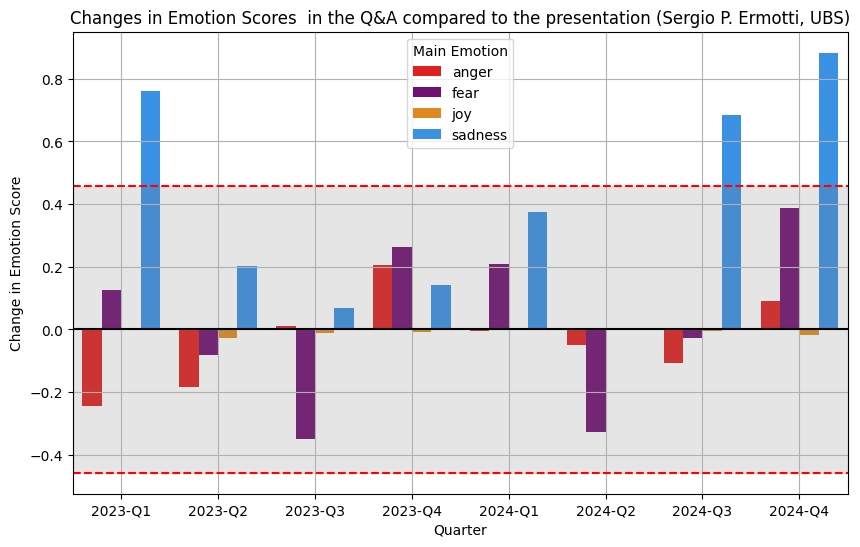

In [58]:
# Plot as changes in emotion as a bar chart
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sergio_ubs_emotion_diff,
    x="quarter",
    y="diff",
    hue="main_emotion",
    palette=emotion_palette
)
# Plot x lines as positive and negative values of sergio_ubs_emotion_std_mean 
plt.axhline(y=sergio_ubs_emotion_std_max, color='r', linestyle='--')
plt.axhline(y=-sergio_ubs_emotion_std_max, color='r', linestyle='--')
# Add grey box between positive and negative standard deviation lines
plt.axhspan(-sergio_ubs_emotion_std_max, sergio_ubs_emotion_std_max, color='grey', alpha=0.2)
# plot x axis at zero
plt.axhline(y=0, color='black', linestyle='-')

# Add numbers to top of bars outside standard deviation range as percentage change

#for p in plt.gca().patches:
#    height = p.get_height()
#    if abs(height) > sergio_ubs_emotion_std_max:
#        plt.gca().annotate(f'{height:.2f}', 
#                           (p.get_x() + p.get_width() / 2., height),
#                           ha='center', va='bottom')
# Add gridlines
plt.grid(True)
plt.title("Changes in Emotion Scores  in the Q&A compared to the presentation (Sergio P. Ermotti, UBS)")
plt.xlabel("Quarter")
plt.ylabel("Change in Emotion Score")
plt.legend(title="Main Emotion")
# Save fig
plt.savefig("changes_in_emotion_scores_sergio_ubs.png")
plt.show()


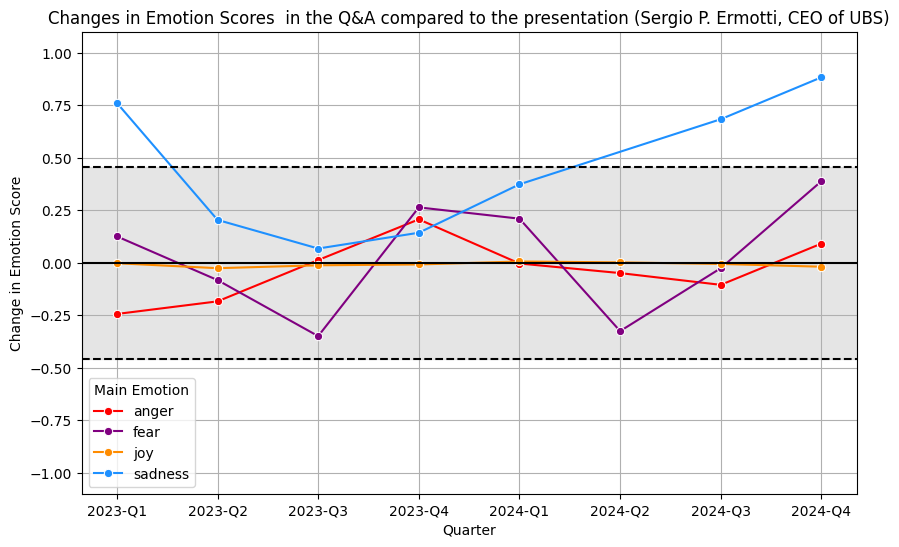

In [59]:
# Replot as line chart for Sergio P. Ermotti, UBS
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=sergio_ubs_emotion_diff,
    x="quarter",
    y="diff",
    hue="main_emotion",
    palette=emotion_palette,
    marker="o"
)
# Fix y scale as -1.1 to + 1.1
plt.ylim(-1.1, 1.1)
plt.axhline(y=sergio_ubs_emotion_std_max, color='black', linestyle='--')
plt.axhline(y=-sergio_ubs_emotion_std_max, color='black', linestyle='--')
plt.axhspan(-sergio_ubs_emotion_std_max, sergio_ubs_emotion_std_max, color='grey', alpha=0.2)
plt.axhline(y=0, color='black', linestyle='-')
# Add gridlines
plt.grid(True)
plt.title("Changes in Emotion Scores  in the Q&A compared to the presentation (Sergio P. Ermotti, CEO of UBS)")
plt.xlabel("Quarter")
plt.ylabel("Change in Emotion Score")
plt.legend(title="Main Emotion")
plt.savefig("changes_in_emotion_scores_sergio_ubs_line.png")
plt.show()

Only significant change in the Q&A emotion after the presentation is the increase in sadness in Q1 2023 plus a rise again Q3 and Q4 2023

# Bank Metrics

In [60]:
met.head(30)

,bank,quarter,metric_name,value,unit,basis
0,JPM,2023-Q1,average_shares_basic,2968.50,count m,reported
1,JPM,2023-Q1,average_shares_diluted,2972.70,count m,reported
2,JPM,2023-Q1,basic_eps,4.11,USD,reported
3,JPM,2023-Q1,cet1_ratio,13.80,percent,reported
4,JPM,2023-Q1,common_shares,2922.30,count m,reported
5,JPM,2023-Q1,credit_loss_expense,2275.00,USD m,managed
6,JPM,2023-Q1,credit_loss_expense,2275.00,USD m,reported
7,JPM,2023-Q1,diluted_eps,4.10,USD,reported
8,JPM,2023-Q1,dividend_per_share,1.00,USD,reported
9,JPM,2023-Q1,equity_attributable_to_shareholders,275678.00,USD m,reported


## Total Revenue

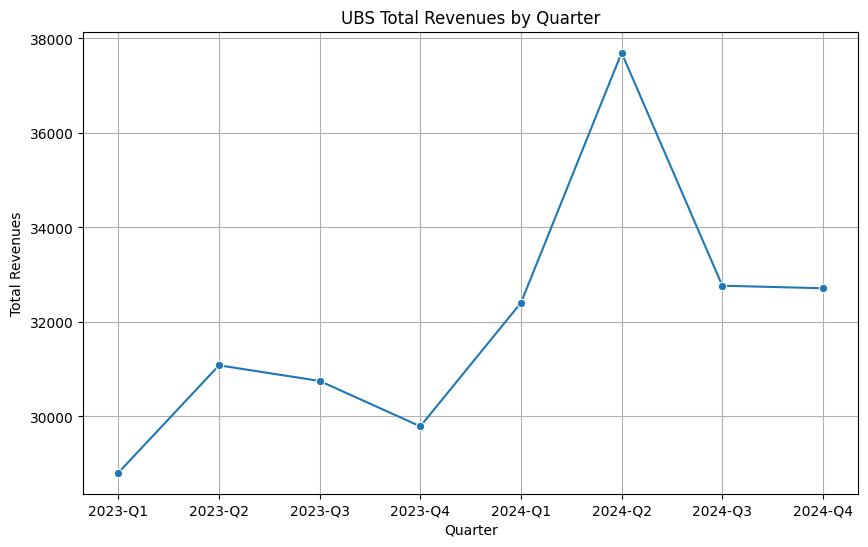

In [61]:
# Plot total revenues  from value by quarter for the filtered data
plt.figure(figsize=(10,6))

met_filtered_tr = met[met['metric_name'] == 'total_revenues']
sns.lineplot(data=met_filtered_tr.groupby('quarter')['value'].mean().reset_index(), x='quarter', y='value', marker='o')

# Add gridlines
plt.grid(True)
plt.xlabel('Quarter')
plt.ylabel('Total Revenues')
plt.title('UBS Total Revenues by Quarter')
# Save Figure
plt.savefig('total_revenues_by_quarter.png')
plt.show()

## Net Profit

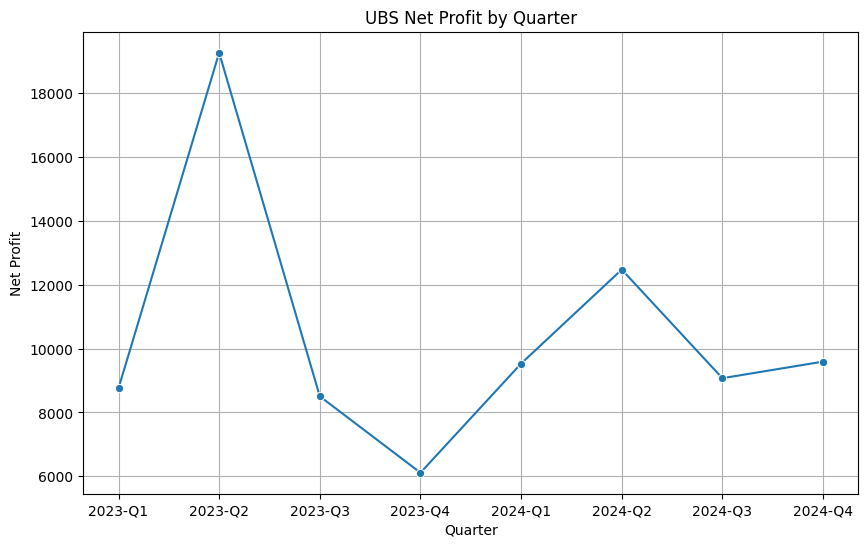

In [62]:
# Filter metric_name by 'net profit'
met_filtered_netp = met[met['metric_name'] == 'net_profit']
met_filtered_netp.head(2)

# Plot net profit from value by quarter for the filtered data
plt.figure(figsize=(10,6))
sns.lineplot(data=met_filtered_netp.groupby('quarter')['value'].mean().reset_index(), x='quarter', y='value', marker='o')

# Add gridlines
plt.grid(True)
plt.xlabel('Quarter')
plt.ylabel('Net Profit')
plt.title('UBS Net Profit by Quarter')
# Save Figure
plt.savefig('net_profit_by_quarter.png')
plt.show()

# Final Scorecard
The aim is to show the Total Revenues and Net Profit by quarter and underneath show the emotion changes in the Q&A by speaker (Todd & Sergio)

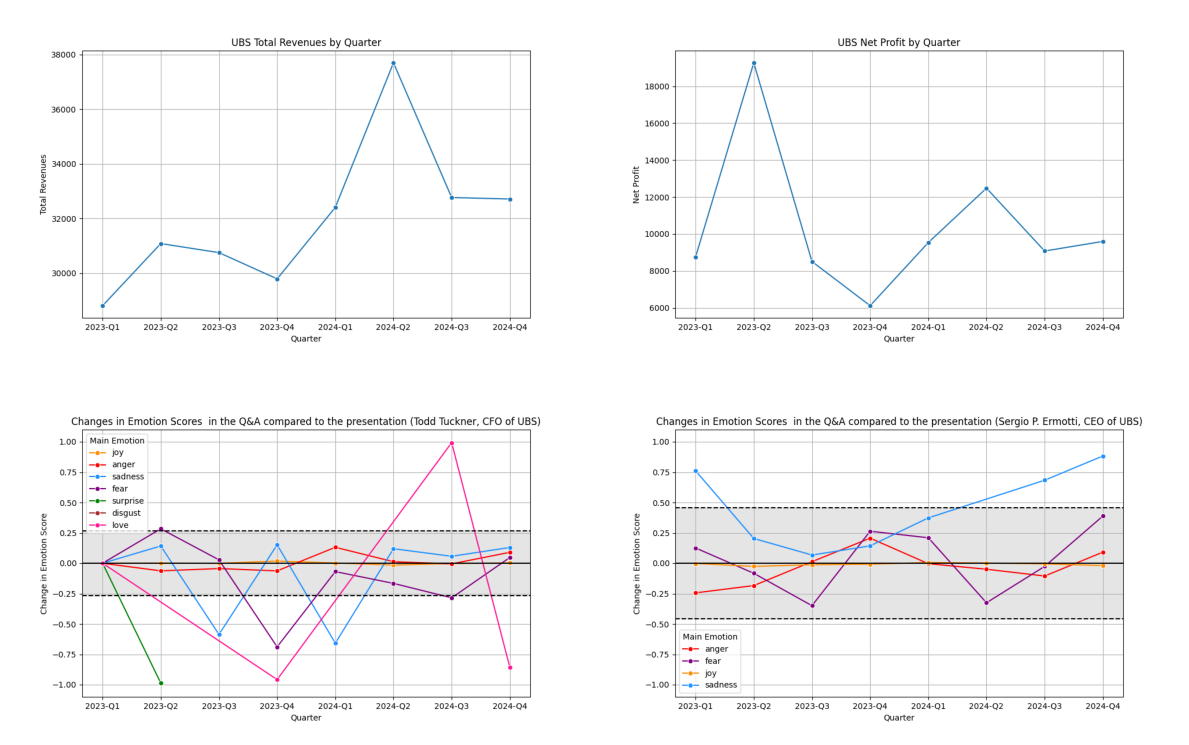

In [63]:
# Build scorecard of 2x2 subplots
metrics = met['metric_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot [0,0] as the total revenues  
img_trq = plt.imread('total_revenues_by_quarter.png')
axes[0, 0].imshow(img_trq)
axes[0, 0].axis('off')


# Plot [0,1] as the net profit
img_np = plt.imread('net_profit_by_quarter.png')
axes[0, 1].imshow(img_np)
axes[0, 1].axis('off')


# Plot [1,0] as Todd Tuckner - emotion changes
img_tt = plt.imread('changes_in_emotion_scores_todd_tuckner_ubs_line.png')
axes[1, 0].imshow(img_tt)
axes[1, 0].axis('off')


# Plot [1,1] as Sergio P. Ermotti - emotion changes
img_se = plt.imread('changes_in_emotion_scores_sergio_ubs_line.png')
axes[1, 1].imshow(img_se)
axes[1, 1].axis('off')


plt.tight_layout()
plt.show()